## Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

## Dataset Path

In [2]:
dataset_path = r"C:\Users\muhammed shabab\Downloads\archive (8)\dataset-resized"

## Image Preprocessing

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## Training Data

In [4]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


## Validation Data

In [5]:
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 503 images belonging to 6 classes.


## Load Pretrained Model

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

## Freeze Pretrained Layers

In [7]:
for layer in base_model.layers:
    layer.trainable = False

## Add Custom Layers

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

## Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 414ms/step - accuracy: 0.7016 - loss: 0.8053 - val_accuracy: 0.7217 - val_loss: 0.6991
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.8592 - loss: 0.3941 - val_accuracy: 0.7435 - val_loss: 0.7180
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.9135 - loss: 0.2568 - val_accuracy: 0.7575 - val_loss: 0.6543
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.9422 - loss: 0.1773 - val_accuracy: 0.7773 - val_loss: 0.6532
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 351ms/step - accuracy: 0.9704 - loss: 0.1214 - val_accuracy: 0.7634 - val_loss: 0.7845
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.9886 - loss: 0.0737 - val_accuracy: 0.7833 - val_loss: 0.7116
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.9951 - loss: 0.0513 - val_accuracy: 0.7833 - val_loss: 0.7438
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.9980 - loss: 0.0331 - val_accu

## Check Accuracy

In [15]:
loss, accuracy = model.evaluate(val_generator)

print("Model Accuracy:", accuracy*100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.7813 - loss: 0.7883
Model Accuracy: 78.1312108039856 %


## Accuracy Graph

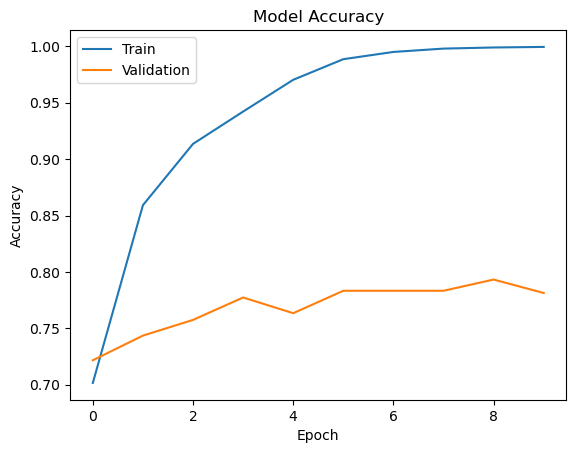

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

## Prediction Code

In [12]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_names = list(train_generator.class_indices.keys())
    result = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(result)
    plt.axis("off")

    print("Prediction:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: cardboard


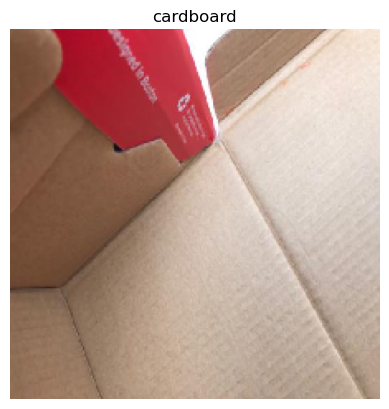

In [20]:
predict_image(r"C:\Users\muhammed shabab\Downloads\archive (8)\dataset-resized\cardboard\cardboard56.jpg")